# Week 02 - Blood Donation EDA

| 항목 | 내용 |
|---|---|
| 이름 | 이성민 |
| 학과 | 소프트웨어융합과 |
| 학년 | 2학년 |
| 학번 | 2151050 |
| 시트 기준 열 | 0320_HomeWork(과제1) |

이 노트북은 과제 요구사항을 학습용으로 재구성한 설명형 산출물이다. 원본 코드를 그대로 복사하지 않고, 같은 개념을 작은 로컬 예제로 다시 구현한다.

## 목표

헌혈 고객 데이터를 프로파일링하고 주요 지표를 EDA로 해석한다.

모든 코드는 외부 서비스 접속 없이 실행되도록 구성했다. 실제 API나 웹사이트를 사용할 때는 같은 처리 흐름에서 데이터 입력 부분만 교체하면 된다.

## 1. EDA 데이터 만들기

헌혈 EDA의 핵심 변수는 최근 헌혈 시점, 총 헌혈 횟수, 총 헌혈량, 첫 헌혈 이후 기간이다. 작은 샘플 데이터를 사용하면 분석 절차를 명확하게 확인할 수 있다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    {"donor_id": "D001", "recency_months": 2, "frequency": 12, "volume_cc": 3000, "tenure_months": 30, "donated_next": 1},
    {"donor_id": "D002", "recency_months": 14, "frequency": 3, "volume_cc": 750, "tenure_months": 18, "donated_next": 0},
    {"donor_id": "D003", "recency_months": 5, "frequency": 8, "volume_cc": 2000, "tenure_months": 26, "donated_next": 1},
    {"donor_id": "D004", "recency_months": 21, "frequency": 2, "volume_cc": 500, "tenure_months": 22, "donated_next": 0},
    {"donor_id": "D005", "recency_months": 1, "frequency": 15, "volume_cc": 3750, "tenure_months": 40, "donated_next": 1},
    {"donor_id": "D006", "recency_months": 9, "frequency": 6, "volume_cc": 1500, "tenure_months": 28, "donated_next": 0},
]
donors = pd.DataFrame(data)
donors

,donor_id,recency_months,frequency,volume_cc,tenure_months,donated_next
0,D001,2,12,3000,30,1
1,D002,14,3,750,18,0
2,D003,5,8,2000,26,1
3,D004,21,2,500,22,0
4,D005,1,15,3750,40,1
5,D006,9,6,1500,28,0


## 2. 프로파일링

프로파일링은 데이터의 크기, 결측치, 자료형, 기초 통계를 확인하는 단계다. 이 단계에서 이상값이나 결측치 처리 전략을 정한다.

In [2]:
profile = pd.DataFrame({
    "dtype": donors.dtypes.astype(str),
    "missing": donors.isna().sum(),
    "unique": donors.nunique(),
})
numeric_summary = donors.select_dtypes(include="number").describe().T

display(profile)
display(numeric_summary)

,dtype,missing,unique
donor_id,object,0,6
recency_months,int64,0,6
frequency,int64,0,6
volume_cc,int64,0,6
tenure_months,int64,0,6
donated_next,int64,0,2


,count,mean,std,min,25%,50%,75%,max
recency_months,6.0,8.666667,7.711463,1.0,2.75,7.0,12.75,21.0
frequency,6.0,7.666667,5.085928,2.0,3.75,7.0,11.00,15.0
volume_cc,6.0,1916.666667,1271.482075,500.0,937.50,1750.0,2750.00,3750.0
tenure_months,6.0,27.333333,7.554248,18.0,23.00,27.0,29.50,40.0
donated_next,6.0,0.500000,0.547723,0.0,0.00,0.5,1.00,1.0


## 3. 파생변수와 구간화

최근성은 낮을수록 최근에 헌혈했다는 뜻이고, 빈도는 높을수록 반복 참여자가 된다. 두 지표를 구간화하면 고객군 해석이 쉬워진다.

In [3]:
def recency_group(months):
    if months <= 3:
        return "recent"
    if months <= 12:
        return "warm"
    return "cold"

def frequency_group(count):
    if count >= 10:
        return "loyal"
    if count >= 5:
        return "regular"
    return "new_or_low"

donors["recency_group"] = donors["recency_months"].apply(recency_group)
donors["frequency_group"] = donors["frequency"].apply(frequency_group)

group_summary = (
    donors.groupby(["recency_group", "frequency_group"], as_index=False)
    .agg(donors=("donor_id", "count"), next_rate=("donated_next", "mean"), avg_volume=("volume_cc", "mean"))
)
group_summary

,recency_group,frequency_group,donors,next_rate,avg_volume
0,cold,new_or_low,2,0.0,625.0
1,recent,loyal,2,1.0,3375.0
2,warm,regular,2,0.5,1750.0


## 4. 시각화와 검증

막대그래프는 그룹별 재헌혈 비율을 비교하는 데 적합하다. 마지막 `assert`는 분석 테이블이 정상 범위를 벗어나지 않았는지 확인한다.

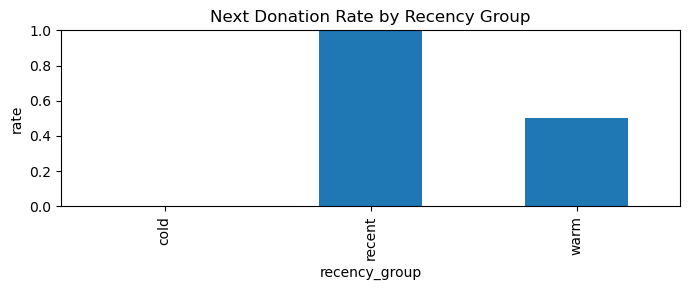

EDA rows: 6 groups: 3


In [4]:
assert donors["volume_cc"].ge(0).all()
assert group_summary["next_rate"].between(0, 1).all()

ax = group_summary.plot(kind="bar", x="recency_group", y="next_rate", figsize=(7, 3), legend=False)
ax.set_title("Next Donation Rate by Recency Group")
ax.set_ylabel("rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("EDA rows:", len(donors), "groups:", len(group_summary))